# Synthetic SHI → Fertilizer ML Model
This notebook trains a machine learning model to predict fertilizer recommendations (Urea, TSP, MoP) based on SHI, soil nutrients, pH, and crop type using a Random Forest Regressor.


In [10]:
pip install scikit-learn


  Using cached scikit_learn-1.7.1-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.16.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.1-cp313-cp313-win_amd64.whl (8.7 MB)
Using cached scipy-1.16.1-cp313-cp313-win_amd64.whl (38.5 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ---------------------

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
# Load dataset
df = pd.read_csv("synthetic_rice_fertilizer_dataset.csv")
df.head()

,SHI,N,P,K,pH,Crop,Urea (kg/ha),TSP (kg/ha),MoP (kg/ha)
0,75,15.70,4.79,44.32,6.20,Aus rice,108.0,75.0,47.0
1,83,15.11,10.23,33.18,7.43,Aus rice,92.6,57.8,17.0
2,77,13.22,6.90,22.37,6.60,Aman rice,107.1,49.3,39.1
3,71,19.00,8.60,43.73,5.12,Aus rice,87.0,44.0,51.0
4,88,16.00,7.86,27.47,7.50,Aus rice,112.2,32.3,26.3


In [18]:
# Encode crop column
le = LabelEncoder()
df['Crop'] = le.fit_transform(df['Crop'])
df.head()

,SHI,N,P,K,pH,Crop,Urea (kg/ha),TSP (kg/ha),MoP (kg/ha)
0,75,15.70,4.79,44.32,6.20,1,108.0,75.0,47.0
1,83,15.11,10.23,33.18,7.43,1,92.6,57.8,17.0
2,77,13.22,6.90,22.37,6.60,0,107.1,49.3,39.1
3,71,19.00,8.60,43.73,5.12,1,87.0,44.0,51.0
4,88,16.00,7.86,27.47,7.50,1,112.2,32.3,26.3


In [19]:
# Features and targets
X = df[['SHI', 'N', 'P', 'K', 'pH', 'Crop']]
y = df[['Urea (kg/ha)', 'TSP (kg/ha)', 'MoP (kg/ha)']]

In [20]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [22]:
# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
# Predict
y_pred = rf.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}, R2: {r2:.2f}")

MSE: 320.75, R2: 0.16


In [24]:
# Example prediction
sample = [[65, 12, 7, 35, 6.5, le.transform(['Boro rice'])[0]]]
sample_scaled = scaler.transform(sample)
pred = rf.predict(sample_scaled)
print(f"Predicted Fertilizer (Urea, TSP, MoP): {pred[0]}")

Predicted Fertilizer (Urea, TSP, MoP): [105.157  52.416  38.708]


c:\Users\safid\Downloads\Fertilizer\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


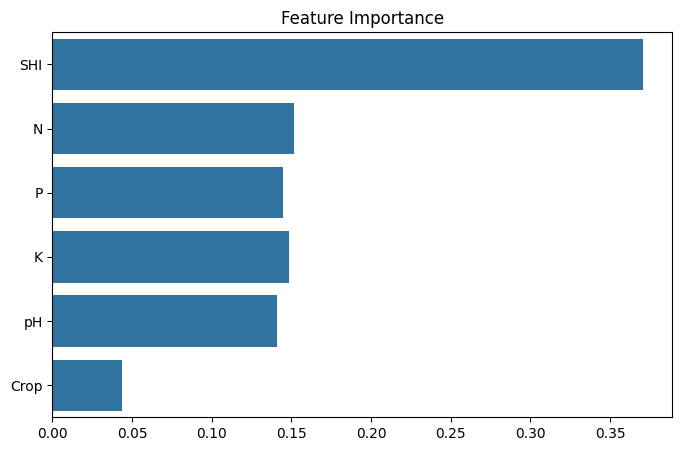

In [25]:
# Feature Importance Visualization
importances = rf.feature_importances_
feature_names = ['SHI', 'N', 'P', 'K', 'pH', 'Crop']

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance")
plt.show()

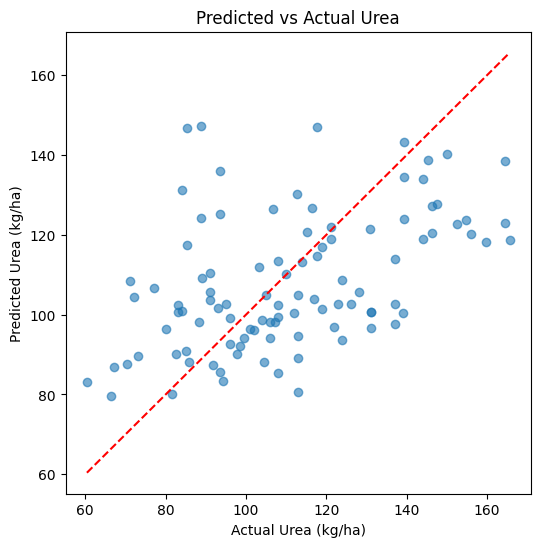

In [26]:
# Predicted vs Actual Scatter Plot for Urea
plt.figure(figsize=(6,6))
plt.scatter(y_test['Urea (kg/ha)'], y_pred[:,0], alpha=0.6)
plt.xlabel("Actual Urea (kg/ha)")
plt.ylabel("Predicted Urea (kg/ha)")
plt.title("Predicted vs Actual Urea")
plt.plot([y_test['Urea (kg/ha)'].min(), y_test['Urea (kg/ha)'].max()], 
         [y_test['Urea (kg/ha)'].min(), y_test['Urea (kg/ha)'].max()], 'r--')
plt.show()